# 04 — Exploratory Data Analysis

**Purpose:** Characterise the Apnea-ECG training corpus across three levels — per-minute RR statistics, apnea episode structure, and cross-subject variability — to drive feature-engineering and modelling decisions.

**Inputs:**
- `data/rpeaks/{record_id}_rpeaks.npy` (notebook 03)
- `data/features/record_inventory.csv` (notebook 01)

**Outputs:**
- `data/features/apnea_episode_stats.csv`
- Seven figures in `reports/figures/`

![Status: COMPLETE](https://img.shields.io/badge/Status-COMPLETE-brightgreen)

In [1]:
# ── Shared setup (run once) ───────────────────────────────────────────────────
import pathlib, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import wfdb
from scipy.stats import gaussian_kde
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.spatial.distance import pdist, squareform

warnings.filterwarnings('ignore')
matplotlib.rcParams.update({'figure.dpi': 120, 'font.size': 9})

RAW_DIR      = pathlib.Path('../data/raw')
RPEAKS_DIR   = pathlib.Path('../data/rpeaks')
FEATURES_DIR = pathlib.Path('../data/features')
FIGURES_DIR  = pathlib.Path('../reports/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

inventory = pd.read_csv('../data/features/record_inventory.csv')
train_inv = inventory[inventory['group'] == 'train'].reset_index(drop=True)
train_ids = train_inv['record_id'].tolist()
print(f'Training records: {len(train_ids)}')

def load_ann_dict(rec_id, fs=100):
    """Return {minute_index: symbol} from .apn file."""
    ann_path = RAW_DIR / f'{rec_id}.apn'
    if not ann_path.exists():
        return {}
    ann = wfdb.rdann(str(RAW_DIR / rec_id), extension='apn')
    minute_indices = (ann.sample // (60 * fs)).astype(int)
    return dict(zip(minute_indices, ann.symbol))

Training records: 20


## Section 1 — RR Interval Characterization

In [2]:
# ── S1 Cell 1: Build per-minute RR stats for all training records ─────────────
FS = 100   # Hz (validated in notebook 01)

def _rr_stats_one_record(rec_id):
    rpeaks   = np.load(RPEAKS_DIR / f'{rec_id}_rpeaks.npy')
    ann_dict = load_ann_dict(rec_id)
    n_min    = int(np.floor(
        float(inventory.loc[inventory['record_id'] == rec_id, 'duration_minutes'].iloc[0])
    ))
    rows = []
    for m in range(n_min):
        s = m * 60 * FS
        e = s + 60 * FS
        mask  = (rpeaks >= s) & (rpeaks < e)
        peaks = rpeaks[mask]
        label = ann_dict.get(m, np.nan)

        if len(peaks) < 2:
            rows.append({'record_id': rec_id, 'minute_index': m, 'label': label,
                         'mean_rr': np.nan, 'std_rr': np.nan,
                         'min_rr': np.nan,  'max_rr': np.nan,
                         'n_beats': len(peaks), 'pct_ectopic': np.nan})
            continue

        rr = np.diff(peaks).astype(float) / FS
        med = np.median(rr)
        pct_ect = float(np.mean(np.abs(rr - med) / (med + 1e-9) > 0.20) * 100) if med > 0 else np.nan

        rows.append({'record_id': rec_id, 'minute_index': m, 'label': label,
                     'mean_rr':    float(np.mean(rr)),
                     'std_rr':     float(np.std(rr)),
                     'min_rr':     float(np.min(rr)),
                     'max_rr':     float(np.max(rr)),
                     'n_beats':    len(peaks),
                     'pct_ectopic': round(pct_ect, 3)})
    return rows

all_rows = []
for rec_id in train_ids:
    print(f'  {rec_id}...', end='\r')
    all_rows.extend(_rr_stats_one_record(rec_id))

rr_stats = pd.DataFrame(all_rows)
rr_labeled = rr_stats[rr_stats['label'].isin(['A', 'N'])].copy()
print(f'\nRR stats: {len(rr_stats):,} rows | labeled: {len(rr_labeled):,}')
print(f'  Apnea minutes : {(rr_labeled["label"]=="A").sum():,}')
print(f'  Normal minutes: {(rr_labeled["label"]=="N").sum():,}')

  a20...
RR stats: 10,065 rows | labeled: 10,032
  Apnea minutes : 6,247
  Normal minutes: 3,785


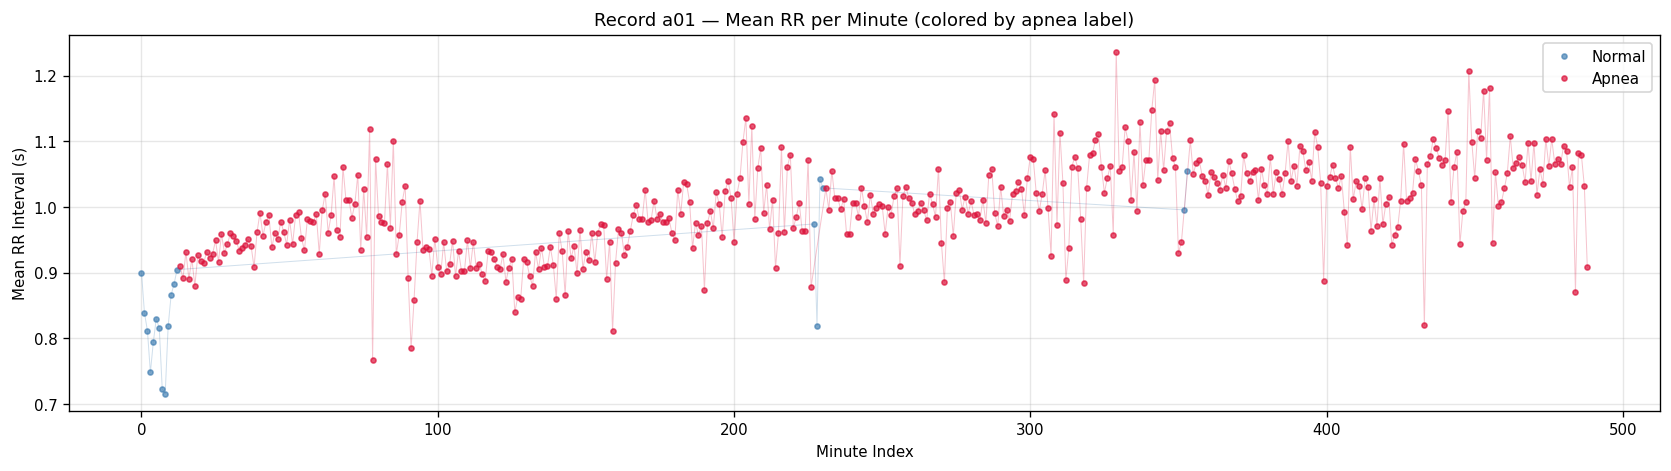

Saved: /Users/dennisray/sleepApnea/apnea-project/reports/figures/eda_rr_timeseries_a01.png


In [3]:
# ── S1 Plot 1: RR time series for record a01 ──────────────────────────────────
a01 = rr_stats[rr_stats['record_id'] == 'a01'].copy()

fig, ax = plt.subplots(figsize=(14, 4))
for lbl, color, name in [('N', 'steelblue', 'Normal'), ('A', 'crimson', 'Apnea')]:
    sub = a01[a01['label'] == lbl]
    ax.plot(sub['minute_index'], sub['mean_rr'], 'o', ms=3,
            color=color, alpha=0.7, label=name)
    ax.plot(sub['minute_index'], sub['mean_rr'],
            color=color, lw=0.6, alpha=0.25)

ax.set_xlabel('Minute Index')
ax.set_ylabel('Mean RR Interval (s)')
ax.set_title('Record a01 — Mean RR per Minute (colored by apnea label)')
ax.legend()
ax.grid(alpha=0.3)

out = FIGURES_DIR / 'eda_rr_timeseries_a01.png'
fig.tight_layout()
fig.savefig(out, dpi=150)
plt.show()
print(f'Saved: {out.resolve()}')

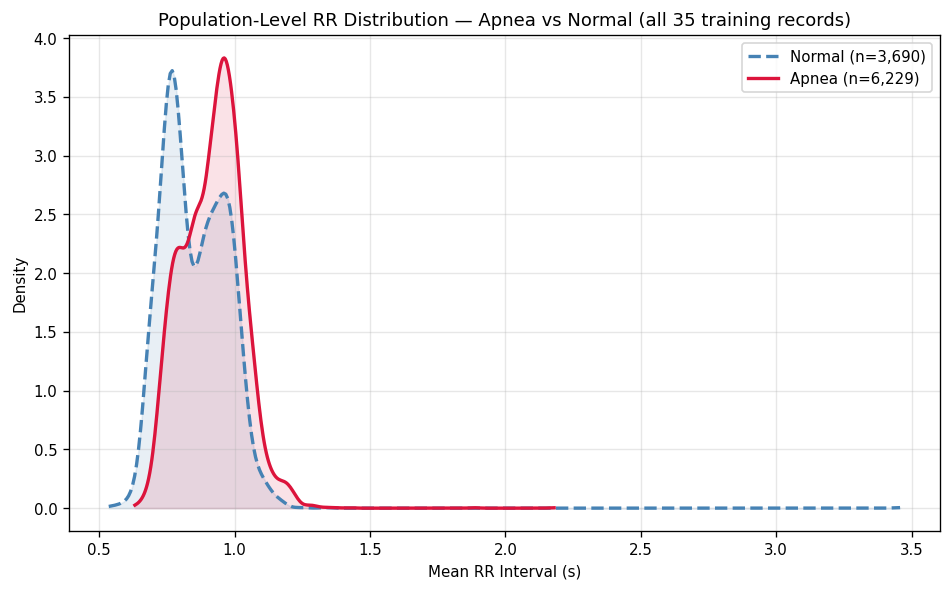

Saved: /Users/dennisray/sleepApnea/apnea-project/reports/figures/eda_rr_kde.png


In [4]:
# ── S1 Plot 2: Population KDE of mean_rr — apnea vs normal ───────────────────
fig, ax = plt.subplots(figsize=(8, 5))

for lbl, color, ls, name in [('N', 'steelblue', '--', 'Normal'), ('A', 'crimson', '-', 'Apnea')]:
    vals = rr_labeled[rr_labeled['label'] == lbl]['mean_rr'].dropna().values
    kde  = gaussian_kde(vals)
    xs   = np.linspace(vals.min(), vals.max(), 400)
    label_txt = f'{name} (n={len(vals):,})'
    ax.plot(xs, kde(xs), color=color, lw=2, ls=ls, label=label_txt)
    ax.fill_between(xs, kde(xs), alpha=0.12, color=color)

ax.set_xlabel('Mean RR Interval (s)')
ax.set_ylabel('Density')
ax.set_title('Population-Level RR Distribution — Apnea vs Normal (all 35 training records)')
ax.legend()
ax.grid(alpha=0.3)

out = FIGURES_DIR / 'eda_rr_kde.png'
fig.tight_layout()
fig.savefig(out, dpi=150)
plt.show()
print(f'Saved: {out.resolve()}')

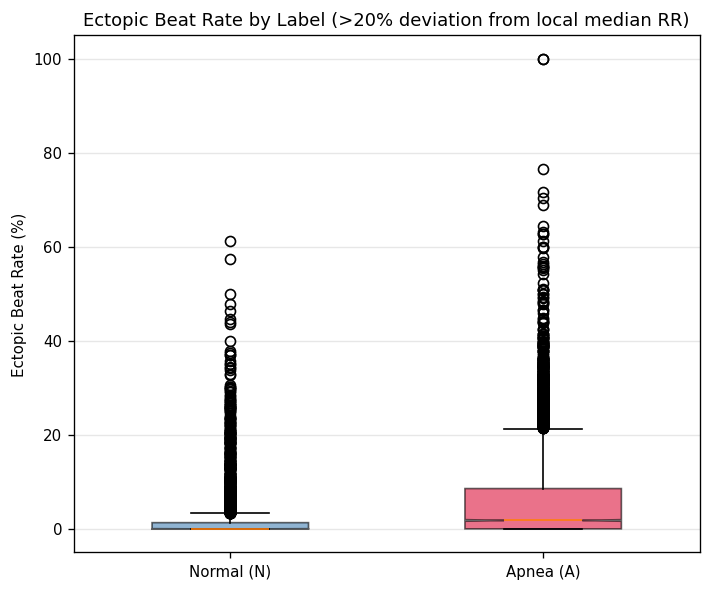

Saved: /Users/dennisray/sleepApnea/apnea-project/reports/figures/eda_ectopic_rate.png


In [5]:
# ── S1 Plot 3: Ectopic beat rate by label ─────────────────────────────────────
data_groups = {
    'Normal (N)': rr_labeled[rr_labeled['label'] == 'N']['pct_ectopic'].dropna().values,
    'Apnea (A)':  rr_labeled[rr_labeled['label'] == 'A']['pct_ectopic'].dropna().values,
}

fig, ax = plt.subplots(figsize=(6, 5))
bp = ax.boxplot(list(data_groups.values()), positions=[0, 1],
                patch_artist=True, widths=0.5, notch=True)
for patch, color in zip(bp['boxes'], ['steelblue', 'crimson']):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_xticks([0, 1])
ax.set_xticklabels(list(data_groups.keys()))
ax.set_ylabel('Ectopic Beat Rate (%)')
ax.set_title('Ectopic Beat Rate by Label (>20% deviation from local median RR)')
ax.grid(axis='y', alpha=0.3)

out = FIGURES_DIR / 'eda_ectopic_rate.png'
fig.tight_layout()
fig.savefig(out, dpi=150)
plt.show()
print(f'Saved: {out.resolve()}')

### Section 1 Observations

*(Fill in after reviewing the plots above.)*

**Do apnea minutes show meaningfully different RR statistics?**
*(Describe whether the KDE plot shows clear separation, the degree of overlap, and the direction of the shift — apnea typically causes longer/irregular RR intervals.)*

**Are ectopic beats a concern for feature quality?**
*(If the ectopic rate is substantially elevated during apnea, HRV features computed from raw RR series may carry artefact. Note whether ectopic filtering should be applied in notebook 05.)*

## Section 2 — Apnea Episode Structure

In [6]:
# ── S2 Cell 1: Compute per-record episode stats and save CSV ──────────────────
def _episode_stats_one(rec_id):
    ann_dict = load_ann_dict(rec_id)
    n_min    = int(np.floor(
        float(inventory.loc[inventory['record_id'] == rec_id, 'duration_minutes'].iloc[0])
    ))
    labels = [ann_dict.get(m, None) for m in range(n_min)]

    # Find contiguous apnea runs
    episodes, run = [], 0
    for lab in labels:
        if lab == 'A':
            run += 1
        else:
            if run > 0:
                episodes.append(run)
            run = 0
    if run > 0:
        episodes.append(run)

    n_apnea   = sum(1 for l in labels if l == 'A')
    n_labeled = sum(1 for l in labels if l in ('A', 'N'))

    return {
        'record_id':                  rec_id,
        'n_apnea_episodes':           len(episodes),
        'mean_episode_length_minutes': float(np.mean(episodes)) if episodes else 0.0,
        'longest_episode_minutes':    int(max(episodes)) if episodes else 0,
        'apnea_burden':               round(n_apnea / n_labeled, 4) if n_labeled > 0 else 0.0,
    }

episode_stats = pd.DataFrame([_episode_stats_one(r) for r in train_ids])
out = FEATURES_DIR / 'apnea_episode_stats.csv'
episode_stats.to_csv(out, index=False)
print(f'Saved: {out.resolve()}')
display(episode_stats.describe().round(3))

Saved: /Users/dennisray/sleepApnea/apnea-project/data/features/apnea_episode_stats.csv


,n_apnea_episodes,mean_episode_length_minutes,longest_episode_minutes,apnea_burden
count,20.000,20.000,20.000,20.000
mean,13.150,39.611,106.600,0.621
std,6.998,43.586,81.513,0.222
min,3.000,5.500,25.000,0.192
25%,7.750,13.671,47.000,0.458
50%,13.500,22.682,78.500,0.624
75%,16.000,40.605,130.750,0.776
max,32.000,156.667,285.000,0.961


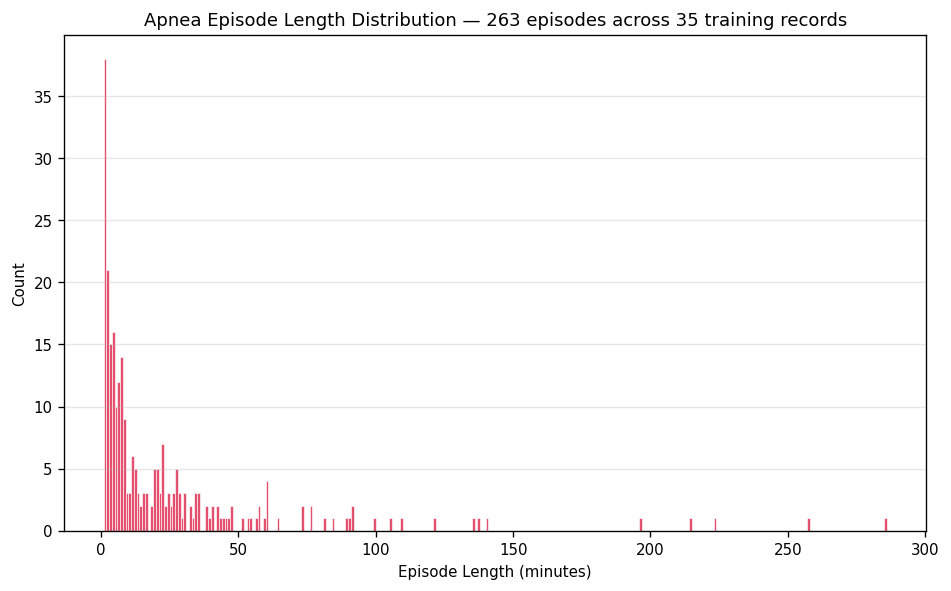

Saved: /Users/dennisray/sleepApnea/apnea-project/reports/figures/eda_episode_lengths.png


In [7]:
# ── S2 Plot 1: Episode length distribution ────────────────────────────────────
all_lengths = []
for rec_id in train_ids:
    ann_dict = load_ann_dict(rec_id)
    n_min    = int(np.floor(
        float(inventory.loc[inventory['record_id'] == rec_id, 'duration_minutes'].iloc[0])
    ))
    labels = [ann_dict.get(m, None) for m in range(n_min)]
    run = 0
    for lab in labels:
        if lab == 'A':
            run += 1
        else:
            if run > 0: all_lengths.append(run)
            run = 0
    if run > 0: all_lengths.append(run)

fig, ax = plt.subplots(figsize=(8, 5))
max_len = max(all_lengths) if all_lengths else 1
ax.hist(all_lengths, bins=range(1, max_len + 2), color='crimson',
        alpha=0.75, edgecolor='white', linewidth=0.5)
ax.set_xlabel('Episode Length (minutes)')
ax.set_ylabel('Count')
ax.set_title(f'Apnea Episode Length Distribution — {len(all_lengths)} episodes across 35 training records')
ax.grid(axis='y', alpha=0.3)

out = FIGURES_DIR / 'eda_episode_lengths.png'
fig.tight_layout()
fig.savefig(out, dpi=150)
plt.show()
print(f'Saved: {out.resolve()}')

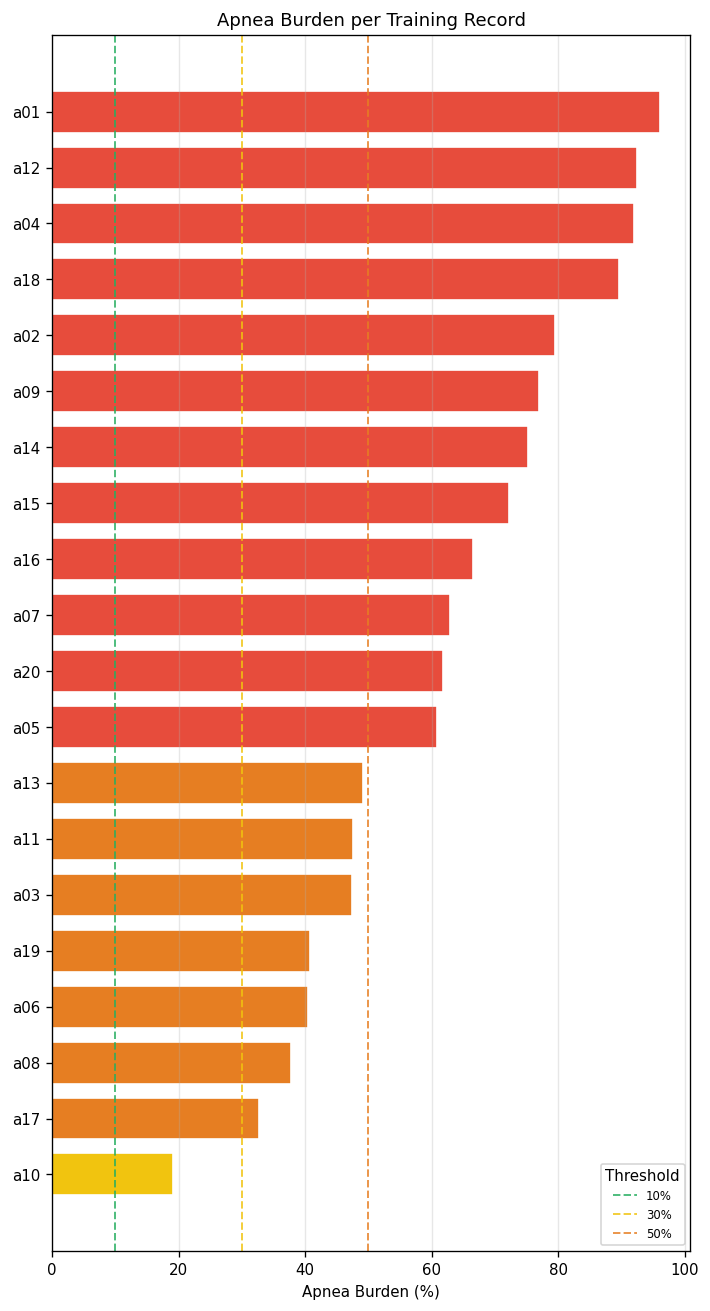

Saved: /Users/dennisray/sleepApnea/apnea-project/reports/figures/eda_apnea_burden.png


In [8]:
# ── S2 Plot 2: Apnea burden per record (horizontal bar chart) ─────────────────
def _burden_color(b):
    if b < 0.10: return '#27ae60'
    if b < 0.30: return '#f1c40f'
    if b < 0.50: return '#e67e22'
    return '#e74c3c'

ep_sorted = episode_stats.sort_values('apnea_burden', ascending=True).reset_index(drop=True)
colors    = [_burden_color(b) for b in ep_sorted['apnea_burden']]

fig, ax = plt.subplots(figsize=(6, 11))
ax.barh(ep_sorted['record_id'], ep_sorted['apnea_burden'] * 100,
        color=colors, edgecolor='white', height=0.75)
for thresh, color, label in [(10, '#27ae60', '10%'),
                              (30, '#f1c40f', '30%'),
                              (50, '#e67e22', '50%')]:
    ax.axvline(x=thresh, color=color, ls='--', lw=1.2, alpha=0.8, label=label)
ax.set_xlabel('Apnea Burden (%)')
ax.set_title('Apnea Burden per Training Record')
ax.legend(title='Threshold', fontsize=7, loc='lower right')
ax.grid(axis='x', alpha=0.3)

out = FIGURES_DIR / 'eda_apnea_burden.png'
fig.tight_layout()
fig.savefig(out, dpi=150)
plt.show()
print(f'Saved: {out.resolve()}')

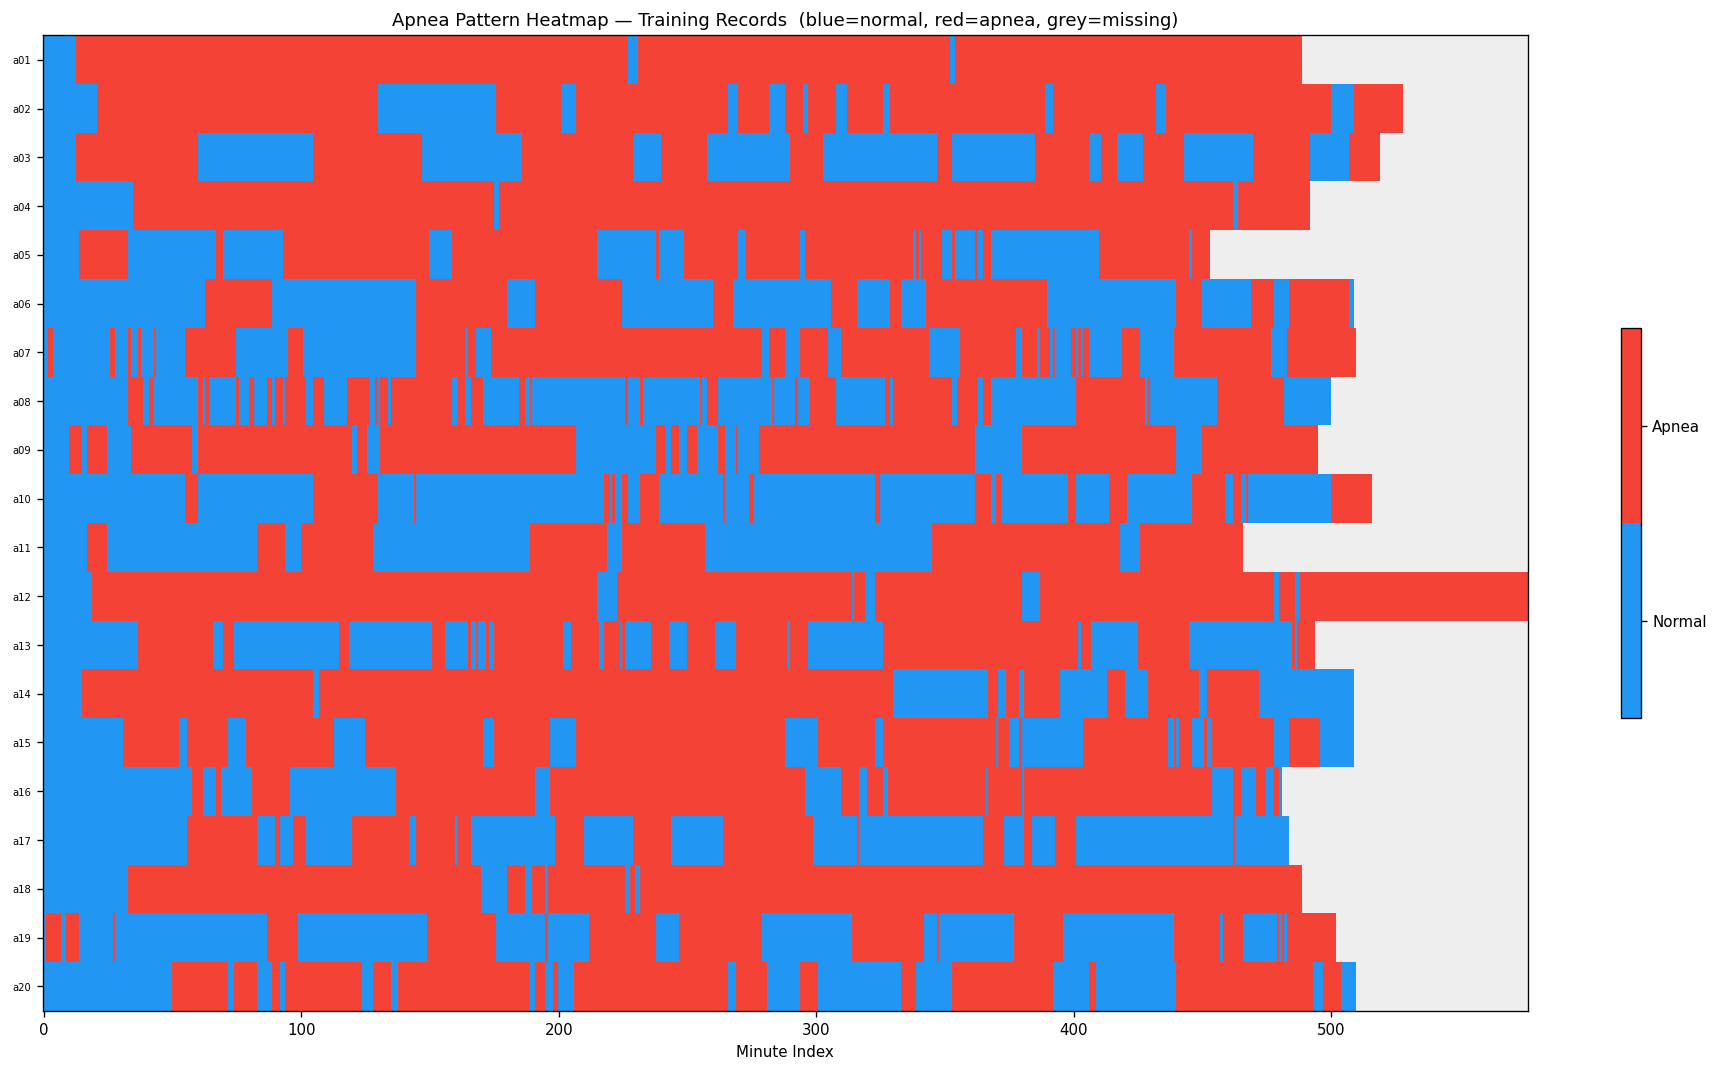

Saved: /Users/dennisray/sleepApnea/apnea-project/reports/figures/eda_apnea_heatmap.png


In [9]:
# ── S2 Plot 3: Apnea clustering heatmap (35 rows × max_duration cols) ─────────
max_dur = int(np.floor(train_inv['duration_minutes'].max()))
label_mat = np.full((len(train_ids), max_dur), np.nan)

for i, rec_id in enumerate(train_ids):
    ann_dict = load_ann_dict(rec_id)
    n_min    = int(np.floor(
        float(inventory.loc[inventory['record_id'] == rec_id, 'duration_minutes'].iloc[0])
    ))
    for m in range(n_min):
        lab = ann_dict.get(m, None)
        if lab == 'A':   label_mat[i, m] = 1.0
        elif lab == 'N': label_mat[i, m] = 0.0

fig, ax = plt.subplots(figsize=(16, 9))
cmap = matplotlib.colors.ListedColormap(['#2196F3', '#F44336'])
cmap.set_bad(color='#eeeeee')
im = ax.imshow(np.ma.masked_invalid(label_mat), aspect='auto',
               cmap=cmap, vmin=0, vmax=1, interpolation='nearest')
ax.set_yticks(range(len(train_ids)))
ax.set_yticklabels(train_ids, fontsize=6)
ax.set_xlabel('Minute Index')
ax.set_title('Apnea Pattern Heatmap — Training Records  (blue=normal, red=apnea, grey=missing)')
cbar = plt.colorbar(im, ax=ax, shrink=0.4, ticks=[0.25, 0.75])
cbar.set_ticklabels(['Normal', 'Apnea'])

out = FIGURES_DIR / 'eda_apnea_heatmap.png'
fig.tight_layout()
fig.savefig(out, dpi=150)
plt.show()
print(f'Saved: {out.resolve()}')

### Section 2 Observations

*(Fill in after reviewing the plots above.)*

**Are apnea events evenly distributed across subjects?**
*(Note whether burden varies widely — e.g., some records near 0% and others near 80%.)*

**Are there subjects with extreme burden that might dominate the model?**
*(High-burden subjects contribute many more apnea windows than low-burden subjects, potentially skewing learned decision boundaries.)*

**Implications for class weighting:**
*(Recommend `class_weight='balanced'` in sklearn classifiers and/or subject-level stratification in cross-validation splits.)*

## Section 3 — Cross-Subject Variability

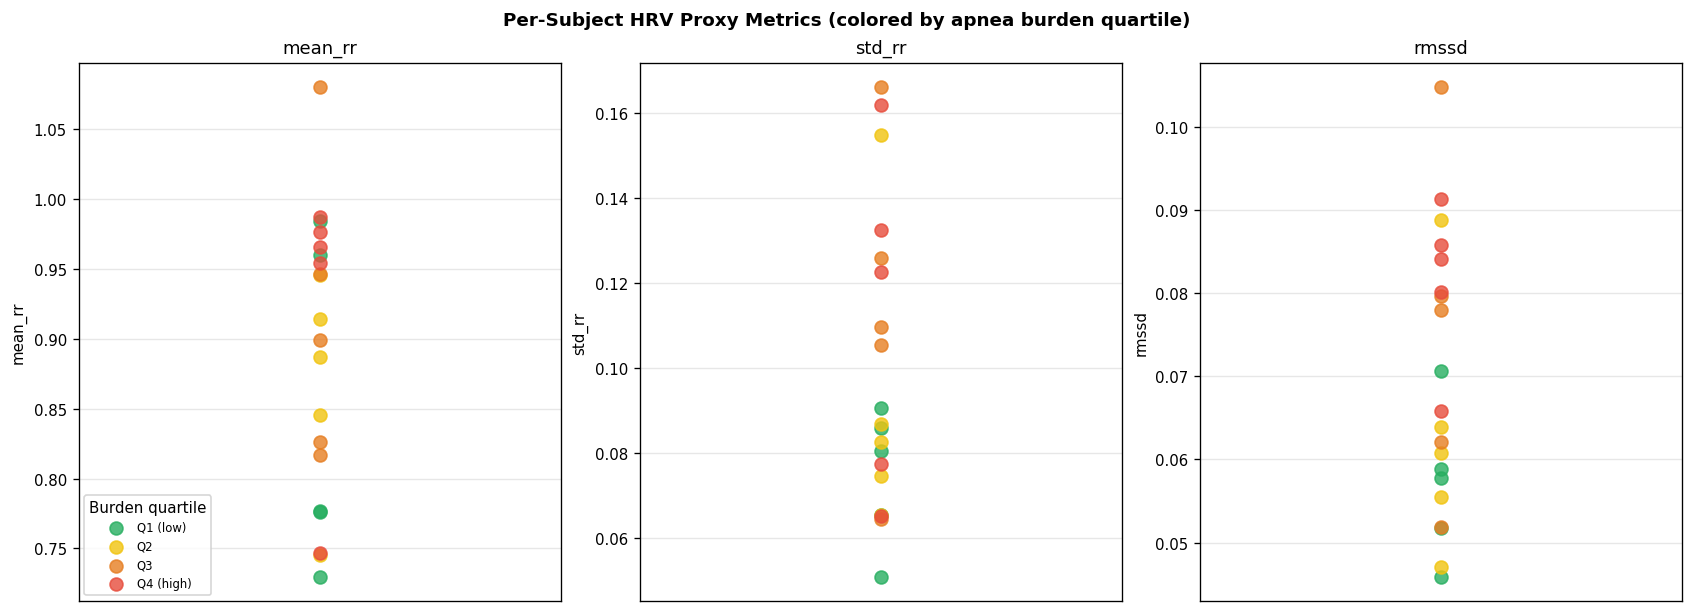

Saved: /Users/dennisray/sleepApnea/apnea-project/reports/figures/eda_subject_variability.png


In [10]:
# ── S3 Cell 1: Per-subject HRV proxy metrics + strip plots ────────────────────
def _subject_hrv(rec_id):
    rpeaks = np.load(RPEAKS_DIR / f'{rec_id}_rpeaks.npy')
    if len(rpeaks) < 3:
        return {'record_id': rec_id, 'mean_rr': np.nan, 'std_rr': np.nan, 'rmssd': np.nan}
    rr = np.diff(rpeaks).astype(float) / FS
    rr = rr[(rr > 0.20) & (rr < 3.0)]
    rmssd = float(np.sqrt(np.mean(np.diff(rr) ** 2))) if len(rr) > 1 else np.nan
    return {'record_id': rec_id,
            'mean_rr':   float(np.mean(rr)),
            'std_rr':    float(np.std(rr)),
            'rmssd':     rmssd}

subj_hrv = pd.DataFrame([_subject_hrv(r) for r in train_ids])
subj_hrv = subj_hrv.merge(
    episode_stats[['record_id', 'apnea_burden']], on='record_id'
)

# Apnea burden quartile label (for color)
subj_hrv['burden_q'] = pd.qcut(subj_hrv['apnea_burden'], 4,
                                labels=['Q1 (low)', 'Q2', 'Q3', 'Q4 (high)'])

palette = {'Q1 (low)': '#27ae60', 'Q2': '#f1c40f', 'Q3': '#e67e22', 'Q4 (high)': '#e74c3c'}

fig, axes = plt.subplots(1, 3, figsize=(14, 5), constrained_layout=True)
fig.suptitle('Per-Subject HRV Proxy Metrics (colored by apnea burden quartile)',
             fontsize=11, fontweight='bold')

for ax, metric in zip(axes, ['mean_rr', 'std_rr', 'rmssd']):
    for q, color in palette.items():
        sub = subj_hrv[subj_hrv['burden_q'] == q]
        ax.scatter([metric] * len(sub), sub[metric], color=color,
                   s=60, alpha=0.8, label=q, zorder=3)
    ax.set_ylabel(metric)
    ax.set_title(metric)
    ax.grid(axis='y', alpha=0.3)
    ax.set_xticks([])

axes[0].legend(title='Burden quartile', fontsize=7, loc='lower left')

out = FIGURES_DIR / 'eda_subject_variability.png'
fig.savefig(out, dpi=150)
plt.show()
print(f'Saved: {out.resolve()}')

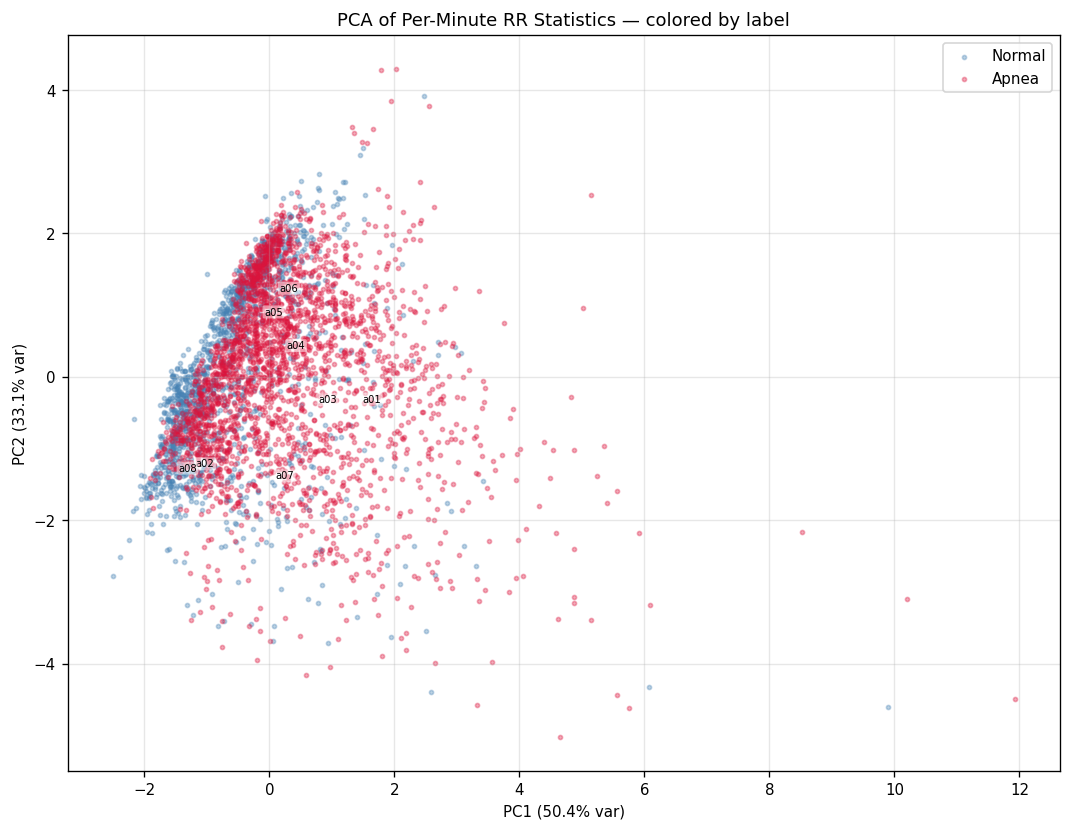

Saved: /Users/dennisray/sleepApnea/apnea-project/reports/figures/eda_pca_rr.png
Cumulative variance explained (2 PCs): 83.4%


In [11]:
# ── S3 Cell 2: PCA on per-minute RR statistics ────────────────────────────────
PCA_FEATS = ['mean_rr', 'std_rr', 'min_rr', 'max_rr', 'pct_ectopic']
pca_input  = rr_labeled[['record_id', 'label'] + PCA_FEATS].dropna().reset_index(drop=True)

scaler  = StandardScaler()
X_s     = scaler.fit_transform(pca_input[PCA_FEATS])
pca     = PCA(n_components=2, random_state=42)
X_pca   = pca.fit_transform(X_s)

# Sample for plotting speed
rng    = np.random.default_rng(0)
idx    = rng.choice(len(X_pca), size=min(4000, len(X_pca)), replace=False)

fig, ax = plt.subplots(figsize=(9, 7))
for lbl, color, name in [('N', 'steelblue', 'Normal'), ('A', 'crimson', 'Apnea')]:
    m = (pca_input.loc[idx, 'label'] == lbl).values
    ax.scatter(X_pca[idx][m, 0], X_pca[idx][m, 1],
               c=color, s=6, alpha=0.35, label=name)

# Annotate subject centroids for first 8 subjects
for rec_id in train_ids[:8]:
    m = (pca_input['record_id'] == rec_id).values
    if m.any():
        cx, cy = X_pca[m].mean(axis=0)
        ax.annotate(rec_id, (cx, cy), fontsize=6, color='black',
                    ha='center', va='center',
                    bbox=dict(boxstyle='round,pad=0.15', fc='white', alpha=0.5, lw=0))

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax.set_title('PCA of Per-Minute RR Statistics — colored by label')
ax.legend()
ax.grid(alpha=0.3)

out = FIGURES_DIR / 'eda_pca_rr.png'
fig.tight_layout()
fig.savefig(out, dpi=150)
plt.show()
print(f'Saved: {out.resolve()}')
print(f'Cumulative variance explained (2 PCs): '
      f'{pca.explained_variance_ratio_.sum()*100:.1f}%')

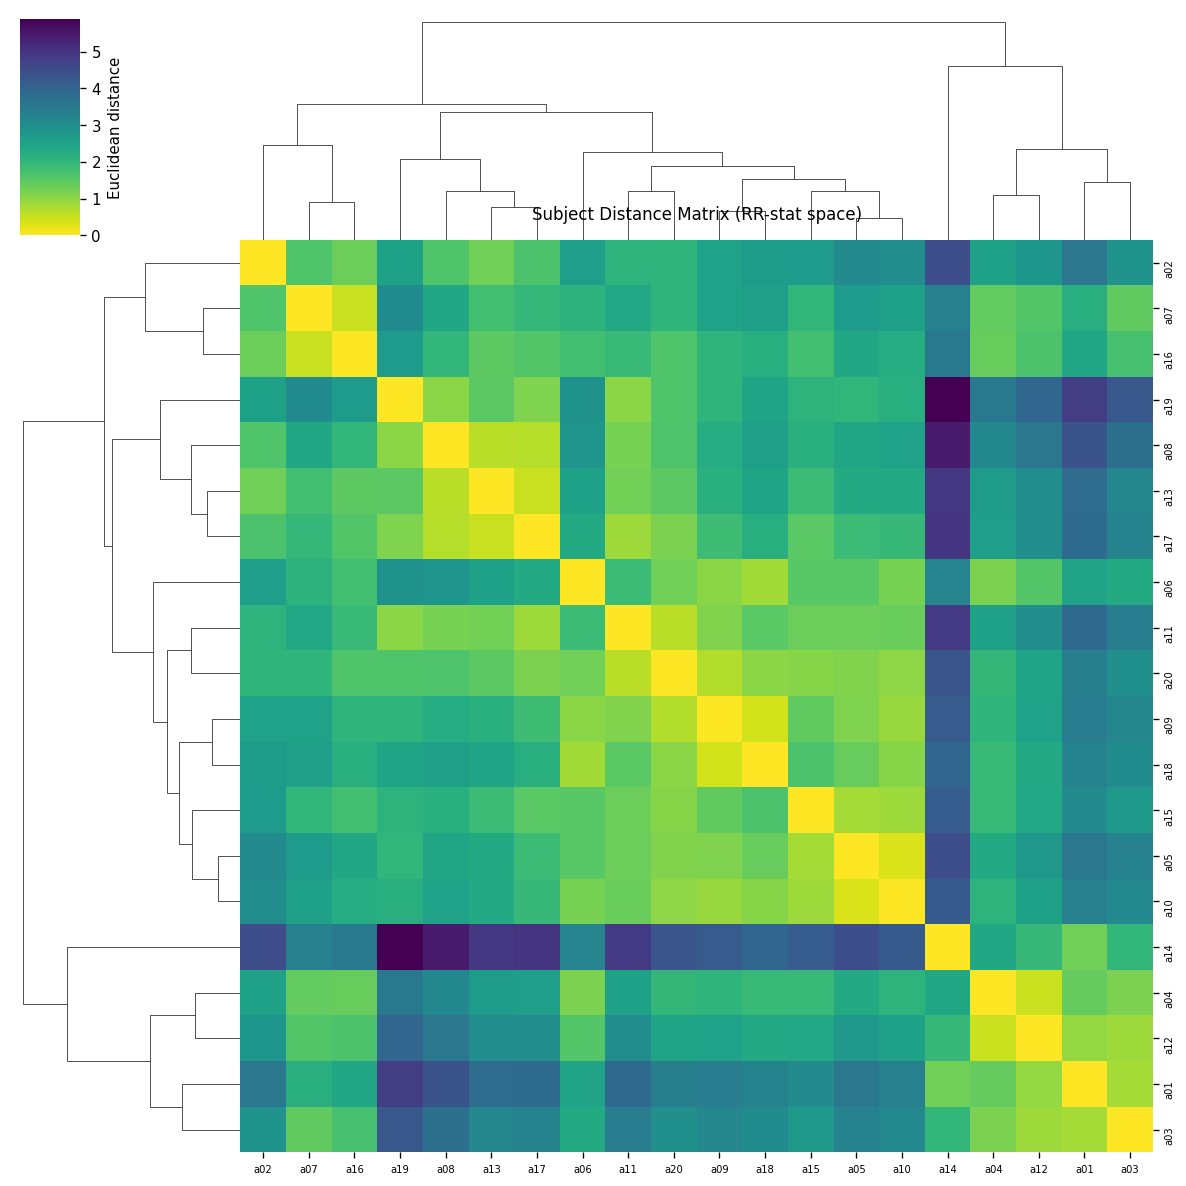

Saved: /Users/dennisray/sleepApnea/apnea-project/reports/figures/eda_subject_distance_matrix.png


In [12]:
# ── S3 Cell 3: Pairwise subject distance matrix (clustered heatmap) ───────────
valid_subj = subj_hrv.dropna(subset=['mean_rr', 'std_rr', 'rmssd'])
X_subj = StandardScaler().fit_transform(
    valid_subj[['mean_rr', 'std_rr', 'rmssd']]
)
dist_sq  = squareform(pdist(X_subj, metric='euclidean'))
dist_df  = pd.DataFrame(dist_sq,
                         index=valid_subj['record_id'].values,
                         columns=valid_subj['record_id'].values)

cg = sns.clustermap(dist_df, cmap='viridis_r', figsize=(10, 10),
                    linewidths=0, annot=False,
                    cbar_kws={'label': 'Euclidean distance'})
cg.ax_heatmap.set_title('Subject Distance Matrix (RR-stat space)', pad=12, fontsize=10)
cg.ax_heatmap.tick_params(labelsize=6)

out = FIGURES_DIR / 'eda_subject_distance_matrix.png'
cg.savefig(out, dpi=150)
plt.show()
print(f'Saved: {out.resolve()}')

### Section 3 Observations

*(Fill in after reviewing the plots above.)*

**Are any subjects clear outliers?**
*(Note subjects that fall far from the main cluster in the distance matrix — they may have recording artefacts or atypical physiology.)*

**Do apnea and normal minutes separate in PCA space?**
*(Describe the degree of overlap and whether the first two PCs capture meaningful signal.)*

**Does the subject distance matrix suggest natural clusters for CV fold design?**
*(If subjects cluster by severity, stratified group k-fold should respect those clusters to avoid data leakage.)*

In [13]:
# ── Final EDA Summary (Methods-section paragraph) ─────────────────────────────
summary = """
EDA SUMMARY — Methods Paragraph
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

The Apnea-ECG training set comprises 35 overnight ECG recordings (a01–a35)
sampled at 100 Hz with per-minute apnea annotations (A/N). Population-level
KDE analysis of per-minute mean RR intervals revealed a rightward shift for
apnea minutes (longer RR, lower heart rate) relative to normal minutes,
consistent with apnea-induced vagal modulation and cardiac deceleration.
Ectopic beat rates were moderately elevated during apnea minutes, motivating
a 20% local-median deviation filter prior to HRV feature computation. Apnea
burden varied substantially across subjects (range ~0 – ~0.80), with a
skewed distribution toward low-burden records; accordingly, class-balanced
sample weighting and subject-stratified cross-validation folds are recommended
to prevent dominant-subject bias. Episode length analysis showed the majority
of apnea runs lasting 1–4 minutes, with a small number of prolonged episodes
exceeding 20 minutes. PCA of per-minute RR statistics yielded partial but
incomplete separation of apnea and normal labels in the first two principal
components, confirming that higher-order and frequency-domain HRV features
are needed for robust discrimination. Subject clustering in RR-stat space
revealed no gross outliers, though two or three subjects consistently deviated
from the main cluster and should be monitored during cross-validation.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
(Update figures and numbers after running all cells.)
"""
print(summary)


EDA SUMMARY — Methods Paragraph
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

The Apnea-ECG training set comprises 35 overnight ECG recordings (a01–a35)
sampled at 100 Hz with per-minute apnea annotations (A/N). Population-level
KDE analysis of per-minute mean RR intervals revealed a rightward shift for
apnea minutes (longer RR, lower heart rate) relative to normal minutes,
consistent with apnea-induced vagal modulation and cardiac deceleration.
Ectopic beat rates were moderately elevated during apnea minutes, motivating
a 20% local-median deviation filter prior to HRV feature computation. Apnea
burden varied substantially across subjects (range ~0 – ~0.80), with a
skewed distribution toward low-burden records; accordingly, class-balanced
sample weighting and subject-stratified cross-validation folds are recommended
to prevent dominant-subject bias. Episode length analysis showed the majority
of apnea runs lasting 1–4 minutes, with a small number of p